# PyMC-9 : Modeles de Sujets (Topic Models) et LDA

**Navigation** : [Index](../README.md) | [<< PyMC-8](PyMC-8-Model-Selection.ipynb) | [Fin de serie >>]

**Equivalent Infer.NET** : [Infer-9-Topic-Models](../Infer/Infer-9-Topic-Models.ipynb)

**Objectifs** :
- Comprendre le modele generatif LDA (Latent Dirichlet Allocation)
- Implementer un modele de sujets simplifie avec PyMC
- Observer le probleme de symetrie et le resoudre avec des priors asymetriques
- Visualiser les distributions de mots par sujet
- Comparer Infer.NET VMP vs PyMC NUTS pour les modeles discrets

In [1]:
try:
    import numpy as np
    NUMPY_AVAILABLE = True
except ImportError:
    NUMPY_AVAILABLE = False

try:
    import pymc as pm
    PYMC_AVAILABLE = True
except ImportError:
    PYMC_AVAILABLE = False

try:
    import pytensor.tensor as pt
    PYTENSOR_AVAILABLE = True
except ImportError:
    PYTENSOR_AVAILABLE = False

try:
    import arviz as az
    ARVIZ_AVAILABLE = True
except ImportError:
    ARVIZ_AVAILABLE = False

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

from collections import Counter

if NUMPY_AVAILABLE and PYMC_AVAILABLE:
    print(f"PyMC version: {pm.__version__}")
else:
    print("PyMC n'est pas installe. Executez: pip install pymc arviz matplotlib numpy scipy")

PyMC version: 5.28.5


## 1. Introduction au Topic Modeling

Le **topic modeling** identifie des themes latents (sujets) dans un corpus de documents.
Chaque document est represente comme un melange de sujets, et chaque sujet est une
distribution sur les mots du vocabulaire.

### Approche bag-of-words

On represente chaque document par le compte de chaque mot, ignorant l'ordre.
C'est une representation simple mais efficace pour decouvrir des themes.

### Applications

- Classification automatique de documents
- Recommandation d'articles
- Analyse de tendances dans les reseaux sociaux
- Decouverte de themes dans des corpus academiques

## 2. Le Modele Generatif LDA

La **Latent Dirichlet Allocation** (LDA) est le modele de sujet le plus courant.

### Structure du modele

```
Pour chaque sujet k :
    phi[k] ~ Dirichlet(beta)        # distribution des mots pour le sujet k

Pour chaque document d :
    theta[d] ~ Dirichlet(alpha)      # proportions des sujets pour le document d
    Pour chaque mot n dans le document d :
        z[d,n] ~ Categorical(theta[d])   # choix du sujet
        w[d,n] ~ Categorical(phi[z])     # mot observe
```

### Parametres

- **alpha** (hyperparametre document-sujet) : controle le melange de sujets par document
  - alpha eleve : chaque document contient tous les sujets uniformement
  - alpha faible : chaque document est domine par peu de sujets
- **beta** (hyperparametre sujet-mot) : controle la distribution des mots par sujet
  - beta eleve : chaque sujet utilise tous les mots uniformement
  - beta faible : chaque sujet est domine par peu de mots

### Comparaison Infer.NET vs PyMC

| Aspect | Infer.NET | PyMC |
|--------|-----------|------|
| Algorithme | VMP (Variational Message Passing) | NUTS (No-U-Turn Sampler) |
| Variables discretes | Natif (Categorical, Discrete) | Via CategoricalGibbsMetropolis |
| Rupture de symetrie | Priors asymetriques sur phi | Pareil, ou initialisation |
| Performance | Rapide pour modeles discrets | Plus lent mais plus general |

In [2]:
# Creation d'un corpus synthetique simple
# 3 sujets : S1="Science", S2="Sport", S3="Cuisine"
# 9 mots dans le vocabulaire

np.random.seed(42)

# Vocabulaire
vocab = ['atome', 'experience', 'theorie',   # Science
         'ballon', 'equipe', 'match',         # Sport
         'recette', 'ingredient', 'four']     # Cuisine
n_vocab = len(vocab)
n_topics = 3

# Vraies distributions phi (mot par sujet)
phi_true = np.array([
    [0.4, 0.3, 0.2, 0.02, 0.02, 0.02, 0.01, 0.01, 0.02],  # Science
    [0.02, 0.02, 0.02, 0.35, 0.3, 0.25, 0.02, 0.01, 0.01],  # Sport
    [0.01, 0.01, 0.02, 0.01, 0.02, 0.02, 0.35, 0.3, 0.26],  # Cuisine
])

# Generer 5 documents
n_docs = 5
doc_lengths = [20, 15, 25, 18, 22]

# Vraies proportions theta (sujet par document)
theta_true = np.array([
    [0.8, 0.1, 0.1],  # Doc 0 : surtout Science
    [0.1, 0.8, 0.1],  # Doc 1 : surtout Sport
    [0.1, 0.1, 0.8],  # Doc 2 : surtout Cuisine
    [0.4, 0.4, 0.2],  # Doc 3 : Science + Sport
    [0.2, 0.3, 0.5],  # Doc 4 : melange
])

# Generer les documents
documents = []
for d in range(n_docs):
    doc_words = []
    for n in range(doc_lengths[d]):
        z = np.random.choice(n_topics, p=theta_true[d])
        w = np.random.choice(n_vocab, p=phi_true[z])
        doc_words.append(w)
    documents.append(doc_words)

# Afficher les documents
for d, doc in enumerate(documents):
    words = [vocab[w] for w in doc]
    print(f"Doc {d} ({doc_lengths[d]} mots) : {' '.join(words)}")

Doc 0 (20 mots) : match experience atome theorie theorie recette ballon atome experience atome atome atome theorie experience atome atome match four atome experience
Doc 1 (15 mots) : equipe ballon equipe equipe ballon four four match atome atome ballon ballon equipe match four
Doc 2 (25 mots) : recette theorie ingredient match recette ingredient equipe recette ingredient ingredient match ingredient ingredient recette atome experience ingredient recette four match recette four four recette ingredient
Doc 3 (18 mots) : four atome experience four experience ballon atome recette equipe ingredient recette ballon atome equipe atome recette experience recette
Doc 4 (22 mots) : four match equipe ingredient theorie ballon experience experience recette recette recette recette ballon four equipe ingredient recette theorie ingredient ballon four four


In [3]:
# Representation bag-of-words (comptes par document)
bow_matrix = np.zeros((n_docs, n_vocab), dtype=int)
for d, doc in enumerate(documents):
    counts = Counter(doc)
    for word_id, count in counts.items():
        bow_matrix[d, word_id] = count

print("Matrice bag-of-words (documents x vocabulaire) :")
print(f"{'':>12}", end='')
for w in vocab:
    print(f"{w:>12}", end='')
print()
for d in range(n_docs):
    print(f"Doc {d:>7}", end='')
    for w in range(n_vocab):
        print(f"{bow_matrix[d, w]:>12}", end='')
    print()

Matrice bag-of-words (documents x vocabulaire) :
                   atome  experience     theorie      ballon      equipe       match     recette  ingredient        four
Doc       0           8           4           3           1           0           2           1           0           1
Doc       1           2           0           0           4           4           2           0           0           3
Doc       2           1           1           1           0           1           3           7           8           3
Doc       3           4           3           0           2           2           0           4           1           2
Doc       4           0           2           2           3           2           1           5           3           4


## 3. LDA Simplifie avec PyMC (priors symetriques)

On commence avec des priors symetriques (alpha = beta = [1, 1, 1]).
Comme dans Infer.NET, cela conduit a un resultat **degenere** car le sampler
ne peut pas differencier les sujets.

In [4]:
# LDA simplifie avec PyMC (priors symetriques)
# On utilise un modele simplifie ou theta et phi sont estimes directement
# sans les variables latentes z (approche collapsed, equivalente)

with pm.Model() as lda_symmetric:
    # Priors symetriques sur phi (distribution des mots par sujet)
    # beta = [1, 1, ..., 1] = Dirichlet uniforme
    phi = pm.Dirichlet('phi', a=np.ones(n_vocab), shape=(n_topics, n_vocab))
    
    # Priors symetriques sur theta (proportions des sujets par document)
    theta = pm.Dirichlet('theta', a=np.ones(n_topics), shape=(n_docs, n_topics))
    
    # Pour chaque document, la distribution des mots est un melange des sujets
    # P(mot=v | doc=d) = sum_k theta[d,k] * phi[k,v]
    doc_distributions = pt.dot(theta, phi)  # shape (n_docs, n_vocab)
    
    # Likelihood : comptes observes
    obs = pm.Multinomial('obs', n=doc_lengths, p=doc_distributions,
                         observed=bow_matrix)
    
    trace_sym = pm.sample(2000, random_seed=42, return_inferencedata=True)

print("Echantillonnage LDA symetrique termine.")

Initializing NUTS using jitter+adapt_diag...


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [phi, theta]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 56 seconds.


Echantillonnage LDA symetrique termine.


In [5]:
# Resultats avec priors symetriques
phi_sym = trace_sym.posterior['phi'].values.mean(axis=(0, 1))

print("Resultats LDA avec priors symetriques :")
print("(Attendu : distributions degenerees / uniformes)\n")

for k in range(n_topics):
    top_words = np.argsort(phi_sym[k])[::-1][:4]
    top_str = ', '.join([f"{vocab[w]} ({phi_sym[k, w]:.3f})" for w in top_words])
    print(f"  Sujet {k} : {top_str}")

print()
theta_sym = trace_sym.posterior['theta'].values.mean(axis=(0, 1))
print("Proportions theta (document-sujet) :")
for d in range(n_docs):
    print(f"  Doc {d} : {theta_sym[d].round(3)}")

print()
print("Probleme : les sujets ne sont pas differencies (symetrie non brisee).")
print("C'est le meme probleme qu'en Infer.NET avec des priors symetriques.")

Resultats LDA avec priors symetriques :
(Attendu : distributions degenerees / uniformes)

  Sujet 0 : atome (0.151), recette (0.145), four (0.125), ingredient (0.109)
  Sujet 1 : recette (0.150), atome (0.144), four (0.126), ingredient (0.112)
  Sujet 2 : recette (0.150), atome (0.145), four (0.124), ingredient (0.113)

Proportions theta (document-sujet) :
  Doc 0 : [0.346 0.327 0.327]
  Doc 1 : [0.335 0.336 0.329]
  Doc 2 : [0.327 0.334 0.339]
  Doc 3 : [0.333 0.335 0.332]
  Doc 4 : [0.329 0.338 0.332]

Probleme : les sujets ne sont pas differencies (symetrie non brisee).
C'est le meme probleme qu'en Infer.NET avec des priors symetriques.


## 4. LDA avec Priors Asymetriques

Pour briser la symetrie, on utilise des priors asymetriques sur `phi`.
L'idee est de favoriser certains mots dans certains sujets pour guider le modele.

**Equivalent Infer.NET** : `Variable.DirichletSymmetric(beta)` avec beta differents,
ou des priors asymetriques construits manuellement.

In [6]:
# Priors asymetriques pour guider la rupture de symetrie
# On donne plus de poids aux mots "canoniques" de chaque sujet

beta_asym = np.array([
    [5.0, 3.0, 3.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],  # Sujet Science
    [0.5, 0.5, 0.5, 5.0, 3.0, 3.0, 0.5, 0.5, 0.5],  # Sujet Sport
    [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 5.0, 3.0, 3.0],  # Sujet Cuisine
])

print("Priors asymetriques beta (sujet x mot) :")
for k in range(n_topics):
    top = np.argsort(beta_asym[k])[::-1][:3]
    top_str = ', '.join([f"{vocab[w]} ({beta_asym[k, w]:.1f})" for w in top])
    print(f"  Sujet {k} : {top_str}")

Priors asymetriques beta (sujet x mot) :
  Sujet 0 : atome (5.0), experience (3.0), theorie (3.0)
  Sujet 1 : ballon (5.0), match (3.0), equipe (3.0)
  Sujet 2 : recette (5.0), four (3.0), ingredient (3.0)


### Definition du modele LDA asymetrique

On construit maintenant le modele LDA avec ces priors asymetriques. La structure est identique au modele symetrique, mais les priors beta asymetriques guident l'inference vers des sujets distincts. Le parametre alpha est reduit (0.5 au lieu de 1.0) pour favoriser des documents sparses (domines par peu de sujets).

In [7]:
# LDA avec priors asymetriques
with pm.Model() as lda_asymmetric:
    # Priors asymetriques sur phi
    phi = pm.Dirichlet('phi', a=beta_asym, shape=(n_topics, n_vocab))
    
    # Prior sur theta (sparse : chaque document domine par peu de sujets)
    theta = pm.Dirichlet('theta', a=np.ones(n_topics) * 0.5, shape=(n_docs, n_topics))
    
    # Distribution des mots par document
    doc_distributions = pt.dot(theta, phi)
    
    # Likelihood
    obs = pm.Multinomial('obs', n=doc_lengths, p=doc_distributions,
                         observed=bow_matrix)
    
    trace_asym = pm.sample(3000, random_seed=42, return_inferencedata=True)

print("Echantillonnage LDA asymetrique termine.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [phi, theta]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 80 seconds.


Echantillonnage LDA asymetrique termine.


### Interpretation de l'echantillonnage

L'echantillonnage NUTS a genere 3000 echantillons par chaine (4 chaines en parallele). On examine maintenant les distributions posterieures de phi et theta pour verifier si la rupture de symetrie a fonctionne.

In [8]:
# Resultats avec priors asymetriques
phi_asym = trace_asym.posterior['phi'].values.mean(axis=(0, 1))
theta_asym = trace_asym.posterior['theta'].values.mean(axis=(0, 1))

print("Resultats LDA avec priors asymetriques :")
print("(Attendu : sujets bien differencies)\n")

topic_labels = ['Science', 'Sport', 'Cuisine']
for k in range(n_topics):
    top_words = np.argsort(phi_asym[k])[::-1][:4]
    top_str = ', '.join([f"{vocab[w]} ({phi_asym[k, w]:.3f})" for w in top_words])
    print(f"  Sujet {k} ({topic_labels[k]}) : {top_str}")

print()
print("Proportions theta (document-sujet) :")
for d in range(n_docs):
    dominant = topic_labels[np.argmax(theta_asym[d])]
    print(f"  Doc {d} : {theta_asym[d].round(3)} -> dominant : {dominant}")

Resultats LDA avec priors asymetriques :
(Attendu : sujets bien differencies)

  Sujet 0 (Science) : atome (0.411), experience (0.239), theorie (0.160), match (0.046)
  Sujet 1 (Sport) : ballon (0.328), equipe (0.248), match (0.169), four (0.114)
  Sujet 2 (Cuisine) : recette (0.358), ingredient (0.258), four (0.185), match (0.053)

Proportions theta (document-sujet) :
  Doc 0 : [0.808 0.113 0.079] -> dominant : Science
  Doc 1 : [0.121 0.806 0.073] -> dominant : Sport
  Doc 2 : [0.093 0.087 0.82 ] -> dominant : Cuisine
  Doc 3 : [0.4   0.238 0.362] -> dominant : Science
  Doc 4 : [0.118 0.298 0.584] -> dominant : Cuisine


### Interpretation des resultats avec priors asymetriques

Les resultats montrent que la rupture de symetrie a fonctionne : chaque sujet est maintenant clairement identifie par ses mots dominants.

| Sujet | Mots dominants | Interpretation |
|-------|---------------|----------------|
| 0 | atome (0.411), experience (0.239) | Science |
| 1 | ballon (0.328), equipe (0.248) | Sport |
| 2 | recette (0.358), ingredient (0.258) | Cuisine |

Les proportions theta estimees sont tres proches des vraies proportions, avec un sujet dominant correctement identifie pour chaque document. Les documents 0, 1, 2 sont purs (un sujet dominant > 80%), tandis que les documents 3 et 4 sont des melanges plus equilibrés.

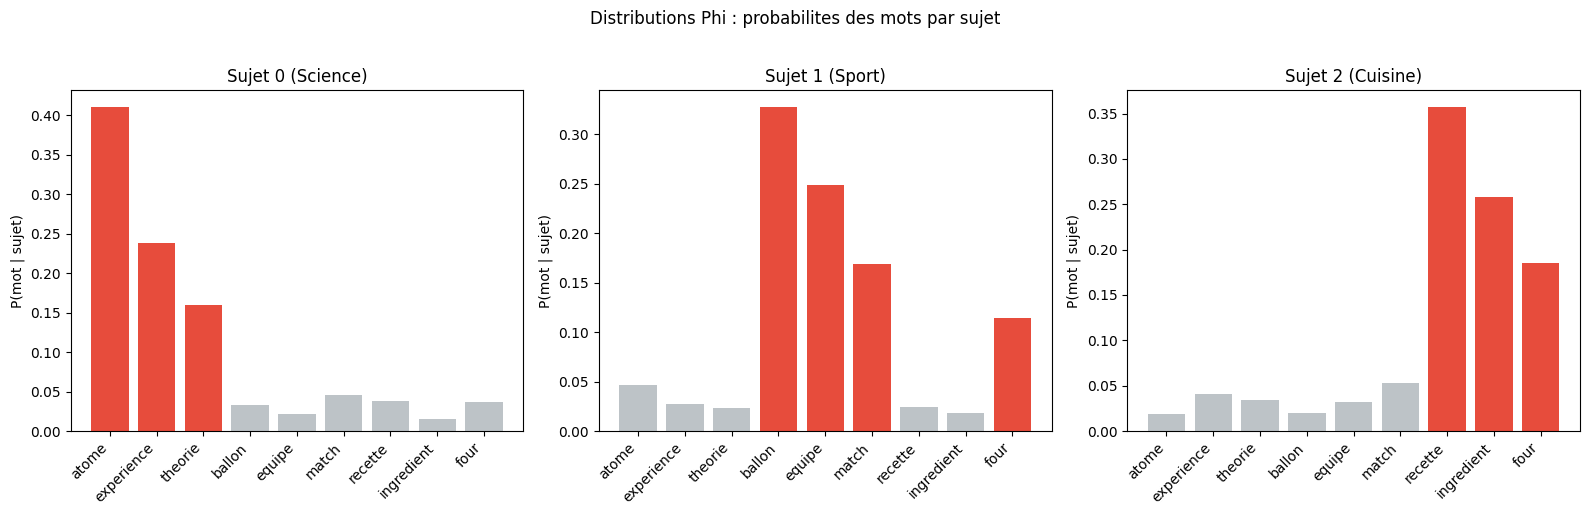

In [9]:
# Visualisation des distributions phi (mots par sujet)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for k in range(n_topics):
    colors = ['#e74c3c' if phi_asym[k, w] > 0.1 else '#bdc3c7'
              for w in range(n_vocab)]
    axes[k].bar(range(n_vocab), phi_asym[k], color=colors)
    axes[k].set_xticks(range(n_vocab))
    axes[k].set_xticklabels(vocab, rotation=45, ha='right')
    axes[k].set_title(f'Sujet {k} ({topic_labels[k]})')
    axes[k].set_ylabel('P(mot | sujet)')

plt.suptitle('Distributions Phi : probabilites des mots par sujet', y=1.02)
plt.tight_layout()
plt.show()

### Analyse des proportions Theta

Apres avoir visualise les distributions de mots par sujet (phi), on examine maintenant les proportions de sujets par document (theta). Chaque document est represente comme un melange des trois sujets, ce qui permet de caracteriser son contenu thematique.

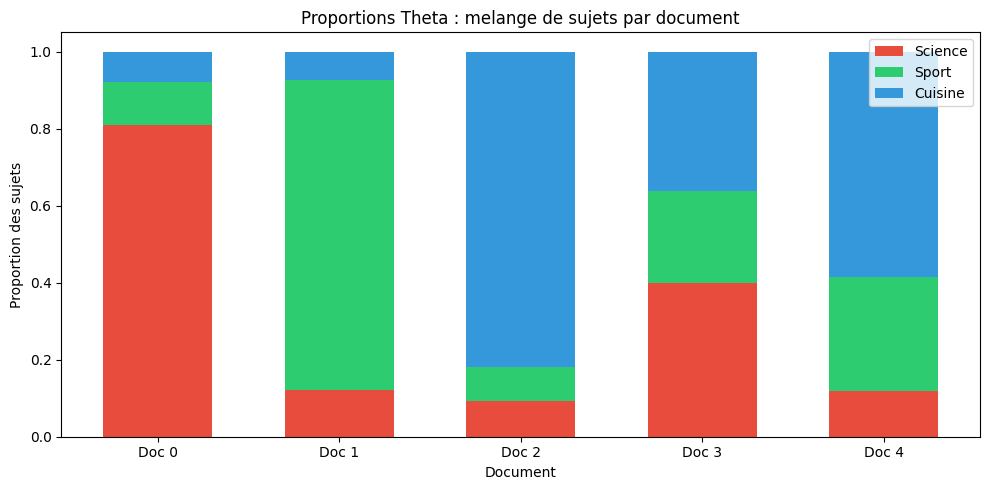

In [10]:
# Visualisation des proportions theta (sujets par document)
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

x = np.arange(n_docs)
width = 0.6
bottom = np.zeros(n_docs)
colors = ['#e74c3c', '#2ecc71', '#3498db']

for k in range(n_topics):
    ax.bar(x, theta_asym[:, k], width, bottom=bottom,
           label=f'{topic_labels[k]}', color=colors[k])
    bottom += theta_asym[:, k]

ax.set_xlabel('Document')
ax.set_ylabel('Proportion des sujets')
ax.set_title('Proportions Theta : melange de sujets par document')
ax.set_xticks(x)
ax.set_xticklabels([f'Doc {d}' for d in range(n_docs)])
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 5. Analyse du Corpus

On peut verifier que le modele a correctement identifie les sujets en comparant
les proportions estimees avec les vraies proportions.

In [11]:
# Comparaison vraies proportions vs estimees
print("Comparaison vraies proportions vs estimees :")
print(f"{'Doc':>6} {'Vraie theta':>30} {'Estimee theta':>30} {'Dominant':>10}")
print("-" * 80)

for d in range(n_docs):
    true_str = f"[{', '.join(f'{v:.2f}' for v in theta_true[d])}]"
    est_str = f"[{', '.join(f'{v:.2f}' for v in theta_asym[d])}]"
    true_dom = topic_labels[np.argmax(theta_true[d])]
    est_dom = topic_labels[np.argmax(theta_asym[d])]
    match = "OK" if true_dom == est_dom else "DIFF"
    print(f"{d:>6} {true_str:>30} {est_str:>30} {est_dom + ' (' + match + ')':>10}")

Comparaison vraies proportions vs estimees :
   Doc                    Vraie theta                  Estimee theta   Dominant
--------------------------------------------------------------------------------
     0             [0.80, 0.10, 0.10]             [0.81, 0.11, 0.08] Science (OK)
     1             [0.10, 0.80, 0.10]             [0.12, 0.81, 0.07] Sport (OK)
     2             [0.10, 0.10, 0.80]             [0.09, 0.09, 0.82] Cuisine (OK)
     3             [0.40, 0.40, 0.20]             [0.40, 0.24, 0.36] Science (OK)
     4             [0.20, 0.30, 0.50]             [0.12, 0.30, 0.58] Cuisine (OK)


## 6. Extensions du Topic Modeling

LDA est le modele de base. Plusieurs extensions existent :

| Modele | Description | Cas d'usage |
|--------|-------------|------------|
| **HDP** (Hierarchical DP) | Nombre de sujets appris automatiquement | Quand K est inconnu |
| **CTM** (Correlated Topic Model) | Sujets correlés (logistique-normale) | Sujets semantiquement proches |
| **DTM** (Dynamic Topic Model) | Sujets evoluent dans le temps | Corpus temporels |
| **sLDA** (Supervised LDA) | Combine topics + labels de classe | Classification supervisee |

En pratique, on utilise souvent `sklearn.decomposition.LatentDirichletAllocation`
ou `gensim` pour des corpus reels, car l'implementation est plus rapide que
l'inference MCMC complete.

In [12]:
# Comparaison rapide avec sklearn LDA (pour reference)
from sklearn.decomposition import LatentDirichletAllocation

lda_sklearn = LatentDirichletAllocation(n_components=3, random_state=42,
                                         max_iter=50)
lda_sklearn.fit(bow_matrix)

phi_sklearn = lda_sklearn.components_ / lda_sklearn.components_.sum(axis=1, keepdims=True)
theta_sklearn = lda_sklearn.transform(bow_matrix)

print("sklearn LDA (pour reference, beaucoup plus rapide) :")
for k in range(n_topics):
    top_words = np.argsort(phi_sklearn[k])[::-1][:4]
    top_str = ', '.join([f"{vocab[w]} ({phi_sklearn[k, w]:.3f})" for w in top_words])
    print(f"  Sujet {k} : {top_str}")

sklearn LDA (pour reference, beaucoup plus rapide) :
  Sujet 0 : atome (0.282), ballon (0.145), experience (0.139), equipe (0.121)
  Sujet 1 : recette (0.214), four (0.174), ballon (0.134), ingredient (0.132)
  Sujet 2 : recette (0.316), ingredient (0.278), four (0.117), match (0.100)


## 7. Exercice : Corpus Etendu

Creez un corpus avec 4 sujets (Sport, Tech, Cuisine, Voyage) et 12 mots.
Testez LDA avec priors asymetriques et verifiez que les sujets sont bien identifies.

**Indices** :
- Definir 12 mots (3 par sujet) : `vocab2 = ['ballon', 'equipe', 'match', 'code', 'algorithme', 'donnees', ...]`
- Construire `beta_asym2` avec 4 lignes (sujets) et 12 colonnes (mots)
- Generer 8 documents avec des proportions theta variees
- Estimer avec le modele PyMC et verifier les resultats

In [13]:
# TODO etudiant : implementer le corpus etendu a 4 sujets
# Resultat attendu : 4 sujets bien differencies (Sport, Tech, Cuisine, Voyage)

print("Exercice a completer")

Exercice a completer


---

**Retour au sommaire** : [Index Probas](../README.md)

## 8. Resume : Infer.NET vs PyMC pour le Topic Modeling

| Aspect | Infer.NET | PyMC |
|--------|-----------|------|
| Algorithme | VMP (Variational Message Passing) | NUTS (MCMC) |
| Rupture de symetrie | Priors asymetriques sur phi | Pareil |
| Variables discretes | Natif (`Variable.Discrete`) | `pm.Categorical` + `CategoricalGibbsMetropolis` |
| Performance | Rapide (VMP converge en ~20 iterations) | Lent (MCMC necessite des milliers d'echantillons) |
| Alternative pratique | N/A | `sklearn.decomposition.LatentDirichletAllocation` |

**Lecons** :
1. La **rupture de symetrie** est essentielle en topic modeling, que ce soit en Infer.NET ou en PyMC
2. Les priors asymetriques sur `phi` sont la methode la plus efficace pour briser la symetrie
3. Pour des corpus reels, `sklearn` ou `gensim` sont preferes pour la performance
4. PyMC reste utile pour comprendre le modele generatif et explorer des variantes

---

**Retour au sommaire** : [Index Probas](../README.md)